<a href="https://colab.research.google.com/github/oliverclaypole/7BUIS010W/blob/main/final_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

#  A.1: Extract S&P 500 tickers from Wikipedia

url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
                  '(KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}
# Adding headers mimics a real browser request, avoiding Wikipedia's 403 block

tables = pd.read_html(url, storage_options=headers)
SP500_tickers = tables[0]
print("S&P 500 table loaded:")
print(SP500_tickers.head())
print(f"Total companies in table: {len(SP500_tickers)}")

# Build ticker list — replace '.' with '-' for Yahoo Finance compatibility
# e.g. BRK.B → BRK-B
ticker_list = [t.replace('.', '-') for t in SP500_tickers['Symbol'].tolist()]
print(f"\nTotal tickers extracted: {len(ticker_list)}")
print(f"Sample tickers: {ticker_list[:10]}")

S&P 500 table loaded:
  Symbol             Security             GICS Sector  \
0    MMM                   3M             Industrials   
1    AOS          A. O. Smith             Industrials   
2    ABT  Abbott Laboratories             Health Care   
3   ABBV               AbbVie             Health Care   
4    ACN            Accenture  Information Technology   

                GICS Sub-Industry    Headquarters Location  Date added  \
0        Industrial Conglomerates    Saint Paul, Minnesota  1957-03-04   
1               Building Products     Milwaukee, Wisconsin  2017-07-26   
2           Health Care Equipment  North Chicago, Illinois  1957-03-04   
3                   Biotechnology  North Chicago, Illinois  2012-12-31   
4  IT Consulting & Other Services          Dublin, Ireland  2011-07-06   

       CIK      Founded  
0    66740         1902  
1    91142         1916  
2     1800         1888  
3  1551152  2013 (1888)  
4  1467373         1989  
Total companies in table: 503

Tot

In [23]:
#  A.2: Download daily price data using yfinance
START_DATE = '2022-01-01'
END_DATE   = '2025-01-01'

print("Downloading S&P 500 price data (this takes 2–4 minutes)...")

stock_data = yf.download(
    ticker_list,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,   # adjusted prices returned under 'Close'
    progress=True
)

stock_prices = stock_data['Close'].copy()

print(f"\nRaw download shape: {stock_prices.shape}")
print(f"Missing values before cleaning: {stock_prices.isna().sum().sum():,}")

[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['Q', 'SNDK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1641013200, endDate = 1735707600")')



Raw download shape: (753, 503)
Missing values before cleaning: 3,651


In [24]:
#  A.3: Identify and remove invalid data
total_days = stock_prices.shape[0]
missing_per_ticker = stock_prices.isna().sum()

# Identify tickers that are missing more than 5% of all trading days
# (these are typically stocks added to the index after Jan 2022)
threshold = 0.05 * total_days
tickers_to_drop = missing_per_ticker[missing_per_ticker > threshold].index.tolist()

print(f"Trading days in dataset  : {total_days}")
print(f"Tickers before cleaning  : {stock_prices.shape[1]}")
print(f"Tickers dropped (>5% NaN): {len(tickers_to_drop)}")
print(f"Dropped: {tickers_to_drop}")

# Drop the heavily incomplete tickers
stock_prices_clean = stock_prices.drop(columns=tickers_to_drop)

# Forward-fill then back-fill any isolated remaining NaNs
stock_prices_clean = stock_prices_clean.ffill().bfill()

print(f"\nTickers after cleaning   : {stock_prices_clean.shape[1]}")
print(f"Remaining NaN values     : {stock_prices_clean.isna().sum().sum()}")
print(f"Final shape              : {stock_prices_clean.shape}")
stock_prices_clean.head()


Trading days in dataset  : 753
Tickers before cleaning  : 503
Tickers dropped (>5% NaN): 7
Dropped: ['GEHC', 'GEV', 'KVUE', 'Q', 'SNDK', 'SOLV', 'VLTO']

Tickers after cleaning   : 496
Remaining NaN values     : 0
Final shape              : (753, 496)


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,151.702179,178.103638,114.894051,172.679993,127.545807,42.362530,380.485291,564.369995,164.526489,60.037266,...,33.979389,85.125778,59.164791,54.760242,110.957481,164.029999,125.887215,120.797722,583.900024,223.051056
2022-01-04,146.573654,175.843246,114.673462,170.800003,124.546158,42.914051,377.766296,554.000000,163.040451,61.151524,...,34.414913,84.854210,59.539253,56.819992,112.134544,156.330002,126.560333,122.023193,587.599976,214.559021
2022-01-05,144.062729,171.165848,115.275818,162.250000,123.986588,42.410072,371.113525,514.429993,160.523590,60.673985,...,33.560604,81.711815,60.122711,57.526688,110.606247,143.490005,124.955940,121.620949,558.179993,206.400620
2022-01-06,144.566879,168.308517,114.732826,159.750000,123.968246,42.657307,353.192322,514.119995,161.034393,61.213432,...,33.828625,82.090073,59.652451,58.879745,110.454369,144.660004,126.246803,120.610634,555.159973,207.220245
2022-01-07,140.718079,168.474838,114.435905,166.050003,124.353531,42.856995,346.418091,510.700012,156.808624,61.735180,...,33.786743,82.002785,60.174953,59.362377,109.571571,141.539993,124.799194,119.880951,530.859985,201.187225


In [25]:
#  A.4: Calculate Daily Returns
# Formula: Daily Return = (Price_today - Price_yesterday) / Price_yesterday
# This is equivalent to pandas .pct_change()

daily_returns = stock_prices_clean.pct_change()
daily_returns.dropna(how='all', inplace=True)  # drop first row (no previous day)

print(f"Daily Returns shape: {daily_returns.shape}")
print(f"\nSample (first 5 rows, first 5 tickers):")
print(daily_returns.iloc[:5, :5].round(6))
print(f"\nAverage daily return across all stocks: {daily_returns.mean().mean()*100:.4f}%")

Daily Returns shape: (752, 496)

Sample (first 5 rows, first 5 tickers):
Ticker             A      AAPL      ABBV      ABNB       ABT
Date                                                        
2022-01-04 -0.033807 -0.012691 -0.001920 -0.010887 -0.023518
2022-01-05 -0.017131 -0.026600  0.005253 -0.050059 -0.004493
2022-01-06  0.003500 -0.016693 -0.004710 -0.015408 -0.000148
2022-01-07 -0.026623  0.000988 -0.002588  0.039437  0.003108
2022-01-10  0.000069  0.000116  0.011195 -0.032159 -0.002213

Average daily return across all stocks: 0.0441%


In [26]:
import pandas as pd
import numpy as np
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# A.5: Calculate Beta
# Formula: Beta = corr(stock_returns, index_returns) × (std_stock / std_index)
# Benchmark: S&P 500 index (^GSPC)

index_raw     = yf.download('^GSPC', start='2022-01-01', end='2025-01-01',
                             auto_adjust=True, progress=False)
index_returns = index_raw['Close'].pct_change().dropna()
# FIX: Ensure index_std is a scalar by selecting the value from the Series
index_std     = index_returns['^GSPC'].std()

# Align stock returns with index returns on matching dates
aligned_stocks, aligned_index = daily_returns.align(
    index_returns, join='inner', axis=0
)

beta_dict = {}
for ticker in aligned_stocks.columns:
    s = aligned_stocks[ticker].dropna()
    # FIX: Ensure 'm' is a Series by explicitly selecting the '^GSPC' column
    m = aligned_index.loc[s.index, '^GSPC']
    if len(s) < 30:
        continue
    corr = s.corr(m)
    beta_dict[ticker] = round(corr * (s.std() / index_std), 4)

beta_series = pd.Series(beta_dict, name='Beta').sort_values(ascending=False)

print(f"Beta calculated for {len(beta_series)} stocks")
print(f"\nBeta summary:")
print(beta_series.describe().round(4))
print(f"\nTop 5 highest beta: \n{beta_series.head()}")
print(f"\nTop 5 lowest beta: \n{beta_series.tail()}")

Beta calculated for 496 stocks

Beta summary:
count    496.0000
mean       0.9437
std        0.4318
min        0.1332
25%        0.6330
50%        0.9117
75%        1.1557
max        3.2941
Name: Beta, dtype: float64

Top 5 highest beta: 
CVNA    3.2941
COIN    2.9610
XYZ     2.5448
NVDA    2.2685
APP     2.2619
Name: Beta, dtype: float64

Top 5 lowest beta: 
LMT    0.2439
HRL    0.2366
SJM    0.1966
CPB    0.1337
GIS    0.1332
Name: Beta, dtype: float64


In [27]:
# A.6: Calculate Annual Volatility
# Formula: Annual Volatility = Daily Return Std Dev × √252
# 252 = standard number of trading days in a year

annual_vol = (daily_returns.std() * np.sqrt(252) * 100).round(4)
annual_vol.name = 'Annual_Volatility_Pct'

print(f"Annual Volatility calculated for {len(annual_vol)} stocks")
print(f"\nVolatility summary (%):")
print(annual_vol.describe().round(4))
print(f"\nMost volatile stocks:")
print(annual_vol.sort_values(ascending=False).head())
print(f"\nLeast volatile stocks:")
print(annual_vol.sort_values().head())

Annual Volatility calculated for 496 stocks

Volatility summary (%):
count    496.0000
mean      31.4300
std       11.4803
min       15.6193
25%       24.0116
50%       28.5016
75%       35.7327
max      134.1039
Name: Annual_Volatility_Pct, dtype: float64

Most volatile stocks:
Ticker
CVNA    134.1039
COIN     95.3848
SMCI     90.1957
APP      78.8374
PLTR     69.0932
Name: Annual_Volatility_Pct, dtype: float64

Least volatile stocks:
Ticker
KO     15.6193
JNJ    16.3759
PEP    17.0397
MCD    17.3512
CL     17.3713
Name: Annual_Volatility_Pct, dtype: float64


In [28]:
#Consolidate all metrics into one DataFrame

mean_return = (daily_returns.mean() * 100).round(6)
mean_return.name = 'Mean_Daily_Return_Pct'

sector_map = SP500_tickers.set_index(
    SP500_tickers['Symbol'].str.replace('.', '-', regex=False)
)['GICS Sector'].to_dict()

metrics_df = pd.DataFrame({
    'Mean_Daily_Return_Pct' : mean_return,
    'Beta'                  : beta_series,
    'Annual_Volatility_Pct' : annual_vol
})
metrics_df['Sector'] = metrics_df.index.map(sector_map)
metrics_df.dropna(inplace=True)
metrics_df.index.name = 'Ticker'

print(f"Master metrics DataFrame: {metrics_df.shape}")
print(metrics_df.head(10))

# Save for Task B
metrics_df.to_csv('sp500_metrics.csv')
print("\nSaved: sp500_metrics.csv")

Master metrics DataFrame: (496, 4)
        Mean_Daily_Return_Pct    Beta  Annual_Volatility_Pct  \
Ticker                                                         
A                   -0.000158  1.0248                29.6259   
AAPL                 0.059113  1.2107                27.0935   
ABBV                 0.060992  0.2991                21.9958   
ABNB                 0.007361  1.6663                46.7875   
ABT                 -0.010575  0.6723                21.7839   
ACGL                 0.116465  0.5698                25.3997   
ACN                  0.001063  1.0942                27.0332   
ADBE                -0.002166  1.4480                38.3083   
ADI                  0.051419  1.3399                31.8058   
ADM                 -0.011053  0.5512                29.4044   

                        Sector  
Ticker                          
A                  Health Care  
AAPL    Information Technology  
ABBV               Health Care  
ABNB    Consumer Discretionary 

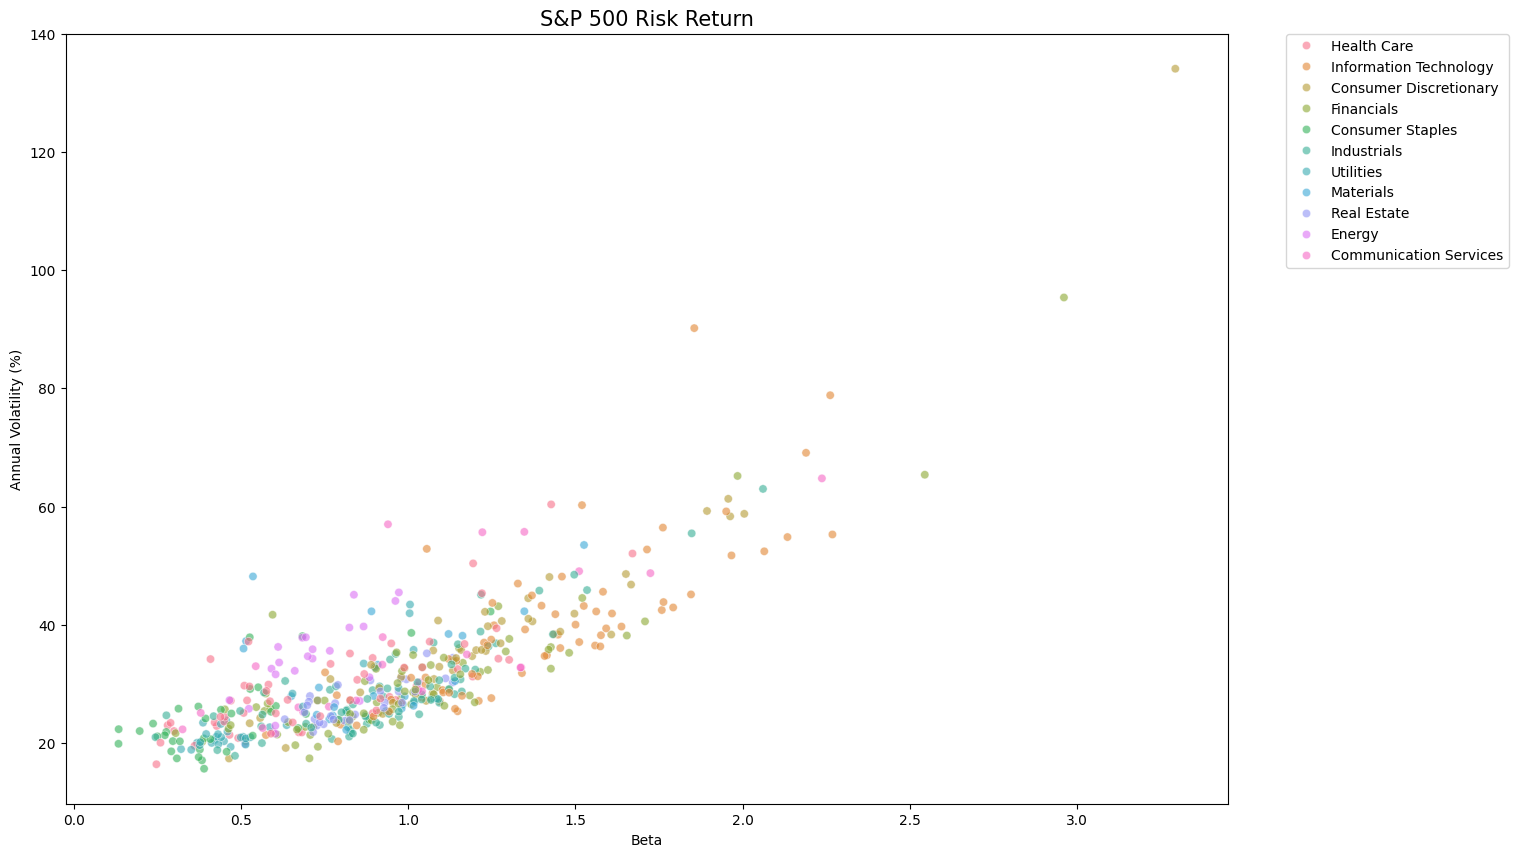

In [29]:
# A.7
# Plots

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))    # creating dimensions

sns.scatterplot(
    data=metrics_df,            # tells the plot where to pull info from
    x='Beta',                   # assigning beta to x axis
    y='Annual_Volatility_Pct',  # assigning annual volatility to y axis
    hue='Sector',               # colour assigns based on sector
    alpha=0.6                   # sets the transparency of the dots
)


plt.title('S&P 500 Risk Return', fontsize=15)                    # plots title
plt.xlabel('Beta')                                               # plots x-axis
plt.ylabel('Annual Volatility (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

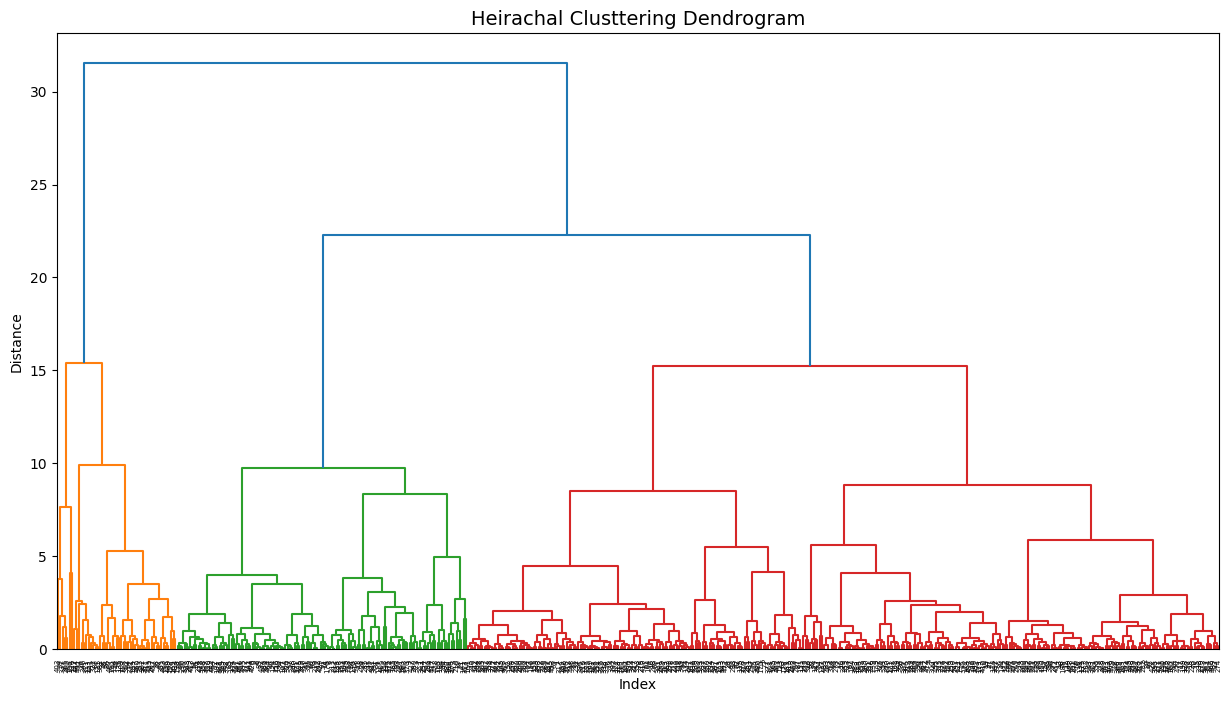

In [30]:
# B.2

import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# scaling the data so beta is not ignored
scaler = StandardScaler()
X_Scaled_Data = scaler.fit_transform(metrics_df[['Mean_Daily_Return_Pct', 'Beta', 'Annual_Volatility_Pct']])

# creates dendriogram
plt.figure(figsize=(15, 8))
linkage_data = sch.linkage(X_Scaled_Data, method='ward')
dendrogram = sch.dendrogram(linkage_data)

plt.title('Heirachal Clusttering Dendrogram', fontsize=14)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.show

Agglomerative Clustering complete.
Cluster label counts:
Agg_Cluster
0    321
1    124
2     51
Name: count, dtype: int64

Cluster profiles (mean values per cluster):
             Mean_Daily_Return_Pct    Beta  Annual_Volatility_Pct
Agg_Cluster                                                      
0                           0.0445  0.7232                25.9383
1                          -0.0023  1.2229                37.0634
2                           0.1541  1.6529                52.2985


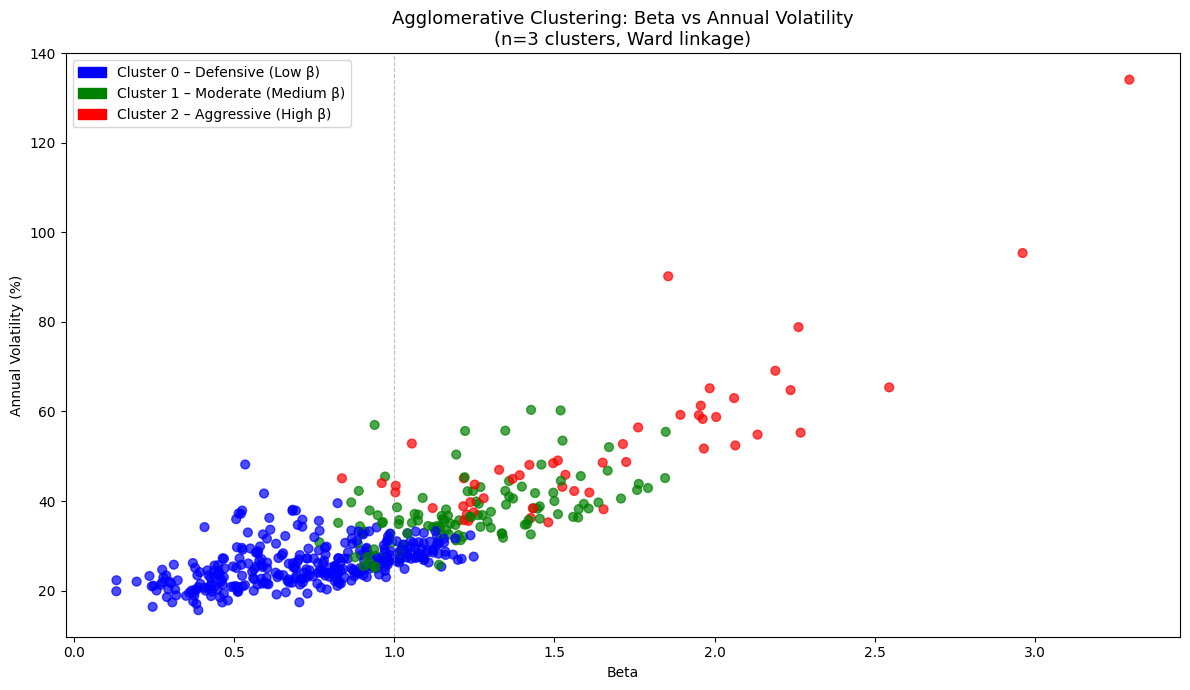

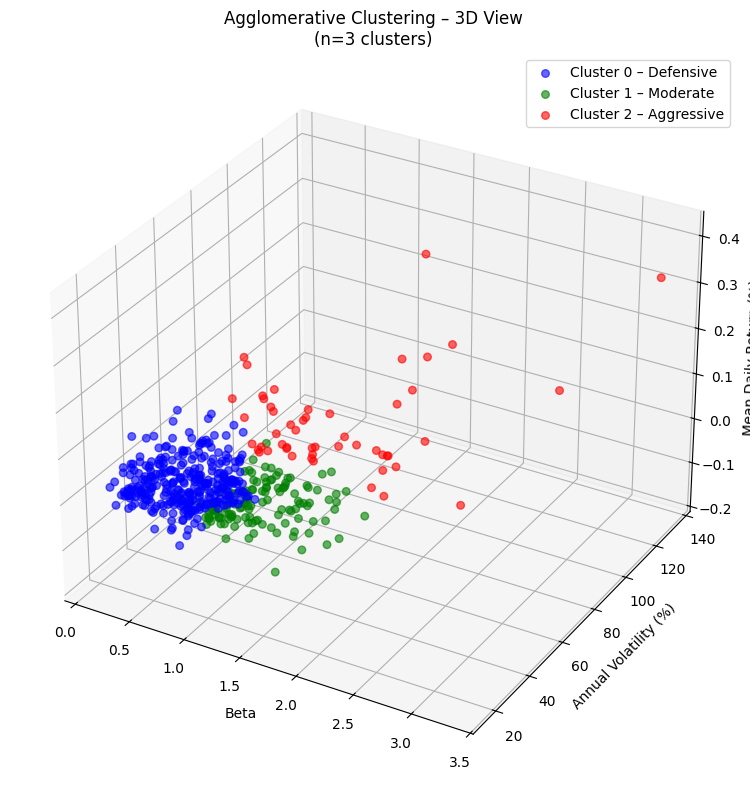


Cluster risk labels assigned:
Agg_Cluster_Label
Defensive (Low β)      321
Moderate (Medium β)    124
Aggressive (High β)     51
Name: count, dtype: int64

Sample stocks per cluster:
  Moderate (Medium β): ['A', 'ABNB', 'ACN', 'ADBE', 'ADI']
  Defensive (Low β): ['AAPL', 'ABBV', 'ABT', 'ACGL', 'ADM']
  Aggressive (High β): ['AMD', 'ANET', 'APO', 'APP', 'ARES']


In [31]:
# B.3  Agglomerative Clustering

# We use n_clusters=3 here, giving us three distinct risk groups.

from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch

agg_model = AgglomerativeClustering(
    n_clusters=3,        # 3 clusters: Defensive, Moderate, Aggressive
    metric='euclidean',  # standard straight-line distance between points
    linkage='ward'       # same Ward criterion as the dendrogram, for consistency
)

# fit_predict gives arbitrary cluster IDs — we re-map them so that
# cluster 0 = lowest beta (Defensive), 1 = middle (Moderate), 2 = highest beta (Aggressive)
raw_labels = agg_model.fit_predict(X_Scaled_Data)
metrics_df['Agg_Cluster_Raw'] = raw_labels

# Rank raw cluster IDs by their mean beta (ascending)
raw_profile = metrics_df.groupby('Agg_Cluster_Raw')['Beta'].mean().sort_values()
beta_rank_map = {raw_id: new_id for new_id, raw_id in enumerate(raw_profile.index)}
metrics_df['Agg_Cluster'] = metrics_df['Agg_Cluster_Raw'].map(beta_rank_map)

# Apply the re-mapping so cluster 0 is always lowest beta
metrics_df['Agg_Cluster'] = metrics_df['Agg_Cluster_Raw'].map(beta_rank_map)

print("Agglomerative Clustering complete.")
print("Cluster label counts:")
print(metrics_df['Agg_Cluster'].value_counts().sort_index())

# Average risk metrics per cluster — confirms ordering is correct
print("\nCluster profiles (mean values per cluster):")
cluster_profile = metrics_df.groupby('Agg_Cluster')[
    ['Mean_Daily_Return_Pct', 'Beta', 'Annual_Volatility_Pct']
].mean().round(4)
print(cluster_profile)

#  2D scatter: Beta vs Annual Volatility
# Cluster 0=blue (Defensive, low β), 1=green (Moderate), 2=red (Aggressive, high β)
import matplotlib.patches as mpatches
cluster_colour_map = {0: 'blue', 1: 'green', 2: 'red'}
point_colours = metrics_df['Agg_Cluster'].map(cluster_colour_map)

plt.figure(figsize=(12, 7))
plt.scatter(
    metrics_df['Beta'],
    metrics_df['Annual_Volatility_Pct'],
    c=point_colours,
    alpha=0.7,
    s=40
)
legend_patches = [
    mpatches.Patch(color='blue',  label='Cluster 0 – Defensive (Low β)'),
    mpatches.Patch(color='green', label='Cluster 1 – Moderate (Medium β)'),
    mpatches.Patch(color='red',   label='Cluster 2 – Aggressive (High β)'),
]
plt.legend(handles=legend_patches)
plt.title('Agglomerative Clustering: Beta vs Annual Volatility\n(n=3 clusters, Ward linkage)', fontsize=13)
plt.xlabel('Beta')
plt.ylabel('Annual Volatility (%)')
plt.axvline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

#  3D scatter: all three dimensions at once
fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111, projection='3d')

colours = {0: 'blue', 1: 'green', 2: 'red'}  # 0=Defensive, 1=Moderate, 2=Aggressive
cluster_names = {0: 'Cluster 0 – Defensive', 1: 'Cluster 1 – Moderate', 2: 'Cluster 2 – Aggressive'}
for cluster_id in sorted(metrics_df['Agg_Cluster'].unique()):
    subset = metrics_df[metrics_df['Agg_Cluster'] == cluster_id]
    ax.scatter(
        subset['Beta'],
        subset['Annual_Volatility_Pct'],
        subset['Mean_Daily_Return_Pct'],
        label=cluster_names[cluster_id],
        color=colours[cluster_id],
        alpha=0.6,
        s=30
    )

ax.set_xlabel('Beta')
ax.set_ylabel('Annual Volatility (%)')
ax.set_zlabel('Mean Daily Return (%)')
ax.set_title('Agglomerative Clustering – 3D View\n(n=3 clusters)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

cluster_labels = {
    0: 'Defensive (Low β)',
    1: 'Moderate (Medium β)',
    2: 'Aggressive (High β)'
}
metrics_df['Agg_Cluster_Label'] = metrics_df['Agg_Cluster'].map(cluster_labels)

print("\nCluster risk labels assigned:")
print(metrics_df['Agg_Cluster_Label'].value_counts())
print("\nSample stocks per cluster:")
for label in metrics_df['Agg_Cluster_Label'].unique():
    sample = metrics_df[metrics_df['Agg_Cluster_Label'] == label].index[:5].tolist()
    print(f"  {label}: {sample}")

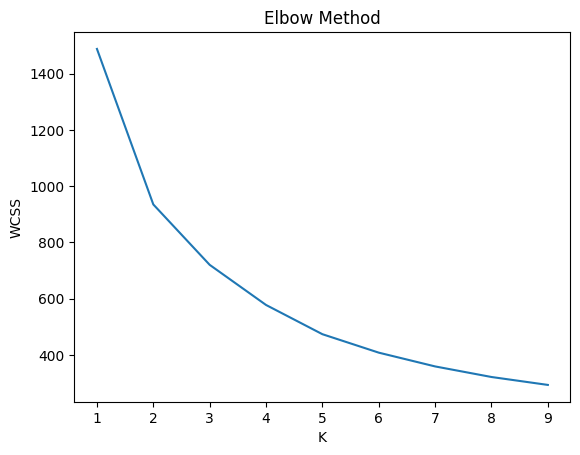

K=2, Score=0.4621945413576434
K=3, Score=0.31096779349663073
K=4, Score=0.32600661076815807
K=5, Score=0.2984665904072348
K=6, Score=0.2913806580967257
K=7, Score=0.2939849615122089
K=8, Score=0.2913589203314171
K=9, Score=0.29133535754810136
         Mean_Daily_Return_Pct      Beta  Annual_Volatility_Pct
Cluster                                                        
0                     0.004759  1.170004              35.985755
1                     0.046942  0.692432              25.277773
2                     0.153019  1.705586              53.244110


In [32]:

# B.6 K-Means
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Use your computed metrics
features = metrics_df[['Mean_Daily_Return_Pct', 'Beta', 'Annual_Volatility_Pct']]

# Scale data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Elbow Method
wcss = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss)
plt.xlabel('K')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

# Silhouette Score
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_features)
    print(f"K={k}, Score={silhouette_score(scaled_features, labels)}")

# Final clustering (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
metrics_df['Cluster'] = kmeans.fit_predict(scaled_features)

# Cluster summary (IMPORTANT – matches your outputs)
cluster_summary = metrics_df.groupby('Cluster')[[
    'Mean_Daily_Return_Pct',
    'Beta',
    'Annual_Volatility_Pct'
]].mean()

print(cluster_summary)

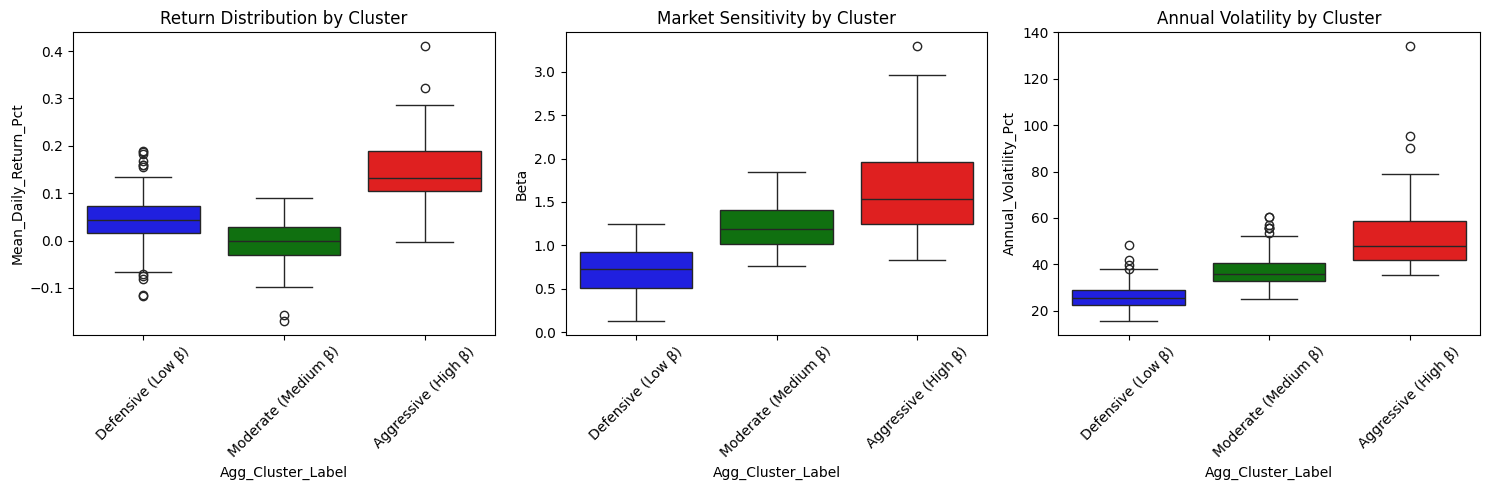

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define a custom color palette based on the cluster_labels mapping
# from the previous Agglomerative Clustering cell (cKDnIJrwLql-)
# Cluster 0: 'Defensive (Low β)' = blue
# Cluster 1: 'Moderate (Medium β)' = green
# Cluster 2: 'Aggressive (High β)' = red
custom_palette = {
    'Aggressive (High β)': 'red',
    'Defensive (Low β)': 'blue',
    'Moderate (Medium β)': 'green'
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(
    x='Agg_Cluster_Label',
    y='Mean_Daily_Return_Pct',
    data=metrics_df,
    ax=axes[0],
    palette=custom_palette, # Use custom palette
    order=['Defensive (Low β)', 'Moderate (Medium β)', 'Aggressive (High β)'] # Ensure consistent order
)
axes[0].set_title('Return Distribution by Cluster')
axes[0].tick_params(axis='x', rotation=45) # Rotate x-axis labels

sns.boxplot(
    x='Agg_Cluster_Label',
    y='Beta',
    data=metrics_df,
    ax=axes[1],
    palette=custom_palette, # Use custom palette
    order=['Defensive (Low β)', 'Moderate (Medium β)', 'Aggressive (High β)'] # Ensure consistent order
)
axes[1].set_title('Market Sensitivity by Cluster')
axes[1].tick_params(axis='x', rotation=45) # Rotate x-axis labels

sns.boxplot(
    x='Agg_Cluster_Label',
    y='Annual_Volatility_Pct',
    data=metrics_df,
    ax=axes[2],
    palette=custom_palette, # Use custom palette
    order=['Defensive (Low β)', 'Moderate (Medium β)', 'Aggressive (High β)'] # Ensure consistent order
)
axes[2].set_title('Annual Volatility by Cluster') # Updated title for clarity
axes[2].tick_params(axis='x', rotation=45) # Rotate x-axis labels

plt.tight_layout()
plt.show()